In [74]:
%pip install geojson
import pandas as pd
import geojson
import pandas as pd
import altair as alt
import json
import matplotlib.pyplot as plt
import numpy as np
%pip install vl-convert-python
import altair as alt
alt.renderers.enable('png')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 19.2 MB/s eta 0:00:00


RendererRegistry.enable('png')

# 1.Data Cleaning

Imported data

In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
df=pd.read_csv("/content/drive/MyDrive/DATA SCIENCE/Data Ethics/Project Data Ethics/Transportation_Network_Providers_-_Trips_(2023-2024)_20260503.csv")

In [77]:
df.head()

,Trip ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Percent Time Chicago,Percent Distance Chicago,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,...,Trip Total,Shared Trip Authorized,Shared Trip Match,Trips Pooled,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
0,ee96b971b42331c8a82eb598248e23ee9b58c95b,01/31/2024 11:45:00 PM,01/31/2024 11:45:00 PM,842,4.2,100%,100%,NaN,NaN,19.0,...,$12.74,True,False,1,41.927261,-87.765502,POINT (-87.7655016086 41.9272609555),41.890609,-87.756047,POINT (-87.7560467111 41.8906088526)
1,eeb26a6dc3a43b08ca43ceac0ff1d80db9dffa9f,01/31/2024 11:45:00 PM,02/01/2024 12:00:00 AM,356,1.3,99%,99%,NaN,NaN,24.0,...,$7.58,False,False,1,41.901207,-87.676356,POINT (-87.6763559892 41.9012069941),41.922761,-87.699155,POINT (-87.6991553432 41.9227606205)
2,eec53d4297b1e4a1a167f140cb209349b2ea1997,01/31/2024 11:45:00 PM,02/01/2024 12:00:00 AM,935,6.5,97%,99%,1.703105e+10,1.703108e+10,5.0,...,$16.07,False,False,1,41.950546,-87.676182,POINT (-87.6761824959 41.9505456965),41.892073,-87.628874,POINT (-87.6288741572 41.8920726347)
3,ef02f4c14488fee23ffb547d2f7a4a8a2a866e3c,01/31/2024 11:45:00 PM,02/01/2024 12:00:00 AM,596,2.4,100%,100%,1.703107e+10,1.703106e+10,7.0,...,$13.23,False,False,1,41.914616,-87.631717,POINT (-87.6317173661 41.9146162864),41.942577,-87.647079,POINT (-87.6470785093 41.942577185)
4,ef4ea3cc3f14628514aa9003257b9bbf61e1b635,01/31/2024 11:45:00 PM,02/01/2024 12:15:00 AM,"1,594",7.2,41%,45%,NaN,NaN,NaN,...,$10.09,True,True,2,NaN,NaN,NaN,41.810879,-87.726363,POINT (-87.7263633246 41.8108790078)


In [78]:
df.shape

(7062191, 24)

In [79]:
#all rideshares

In [80]:
df.columns

Index(['Trip ID', 'Trip Start Timestamp', 'Trip End Timestamp', 'Trip Seconds',
       'Trip Miles', 'Percent Time Chicago', 'Percent Distance Chicago',
       'Pickup Census Tract', 'Dropoff Census Tract', 'Pickup Community Area',
       'Dropoff Community Area', 'Fare', 'Tip', 'Additional Charges',
       'Trip Total', 'Shared Trip Authorized', 'Shared Trip Match',
       'Trips Pooled', 'Pickup Centroid Latitude', 'Pickup Centroid Longitude',
       'Pickup Centroid Location', 'Dropoff Centroid Latitude',
       'Dropoff Centroid Longitude', 'Dropoff Centroid Location'],
      dtype='object')

First of all I need to filter given on conditions


All of the rides need to be in Chicago
*   Percent Time Chicago Percent of the trip time that was in Chicago.
*   Percent Distance Chicago NEW IN THIS DATASET: Percent of the trip distance that was in Chicago
* Pickup Census Tract The Census Tract where the trip began.This column often will be blank for locations outside Chicago.
* Dropoff Census Tract The Census Tract where the trip ended. This column often will be blank for locations outside Chicago.
* Pickup Community Area The Community Area where the trip began. This column will be blank for locations outside Chicago.
* Dropoff Community Area

Then all of the rides need to be private- no shared

* Shared Trip Authorized Whether the customer agreed to a shared trip with another customer, regardless of whether the customer was actually matched for a shared trip.
* Shared Trip Match NEW IN THIS DATASET: Whether the customer was actually matched to a shared trip.
* Trips Pooled
If customers were matched for a shared trip, how many trips, including this one, were pooled. All customer trips from the time the vehicle was empty until it was empty again contribute to this count, even if some customers were never present in the vehicle at the same time. Each trip making up the overall shared trip will have a separate record in this dataset, with the same value in this column.



In [81]:
df['Percent Time Chicago'].unique()
df['Percent Distance Chicago'].unique()
df['Pickup Census Tract'].unique()
df['Dropoff Census Tract'].unique()
df['Pickup Community Area'].unique()
df['Dropoff Community Area'].unique()

array([25., 22.,  8.,  6., 57., nan, 28.,  7., 76., 34., 60., 44., 32.,
       43.,  3., 67.,  2., 29., 38., 65., 49., 41., 37., 36., 16., 24.,
       64., 52., 59., 13., 48., 30., 77., 46., 68.,  1., 45., 69., 71.,
       14.,  4., 19., 39., 33., 15., 70., 26., 20., 11., 58., 35., 63.,
       17., 23., 42., 40.,  5., 27., 10., 53., 21., 61., 31., 62., 55.,
       66., 54., 72., 75.,  9., 74., 73., 18., 12., 56., 51., 47., 50.])

In [82]:
df['Shared Trip Authorized'].unique()
#df['Shared Trip Match'].unique()

array([ True, False])

Filtering on conditions whethere shared trip authoried is true then drop and also if dropoff community area or pickup community area is NAN

In [83]:
df1=df.copy()
df1.drop(df1[df1['Shared Trip Authorized']==True].index,inplace=True)
df1.drop(df1[df1['Dropoff Community Area'].isna()].index,inplace=True)
df1.drop(df1[df1['Pickup Community Area'].isna()].index,inplace=True)
df1.drop(df1[df1['Pickup Census Tract'].isna()].index,inplace=True)
df1.drop(df1[df1['Dropoff Census Tract'].isna()].index,inplace=True)
df1.shape

(3777970, 24)

At this point I have 3,777,970 - 3.7 million points

In [84]:
df1.drop(df1[df1['Fare'].isna()].index,inplace=True)
df1.isna().sum()

,0
Trip ID,0
Trip Start Timestamp,0
Trip End Timestamp,0
Trip Seconds,0
Trip Miles,0
Percent Time Chicago,5
Percent Distance Chicago,359
Pickup Census Tract,0
Dropoff Census Tract,0
Pickup Community Area,0


In [85]:
df1.head()

,Trip ID,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Percent Time Chicago,Percent Distance Chicago,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,...,Trip Total,Shared Trip Authorized,Shared Trip Match,Trips Pooled,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
2,eec53d4297b1e4a1a167f140cb209349b2ea1997,01/31/2024 11:45:00 PM,02/01/2024 12:00:00 AM,935,6.5,97%,99%,1.703105e+10,1.703108e+10,5.0,...,$16.07,False,False,1,41.950546,-87.676182,POINT (-87.6761824959 41.9505456965),41.892073,-87.628874,POINT (-87.6288741572 41.8920726347)
3,ef02f4c14488fee23ffb547d2f7a4a8a2a866e3c,01/31/2024 11:45:00 PM,02/01/2024 12:00:00 AM,596,2.4,100%,100%,1.703107e+10,1.703106e+10,7.0,...,$13.23,False,False,1,41.914616,-87.631717,POINT (-87.6317173661 41.9146162864),41.942577,-87.647079,POINT (-87.6470785093 41.942577185)
6,efc576b4be2535b5a835a4c33f97ea6005392ca2,01/31/2024 11:45:00 PM,02/01/2024 12:00:00 AM,"1,315",8.7,100%,100%,1.703108e+10,1.703183e+10,8.0,...,$18.47,False,False,1,41.892042,-87.631864,POINT (-87.6318639497 41.8920421365),41.879067,-87.657005,POINT (-87.657005027 41.8790669938)
8,efdb8a50e1375c89c226ff1a59ae2c620c51406e,01/31/2024 11:45:00 PM,02/01/2024 12:00:00 AM,341,1.0,100%,100%,1.703108e+10,1.703108e+10,8.0,...,$7.32,False,False,1,41.892508,-87.626215,POINT (-87.6262149064 41.8925077809),41.902788,-87.626146,POINT (-87.6261455896 41.9027880476)
14,f07e5f06a5e9ad1ed6bc139d624804e0f1b2fea4,01/31/2024 11:45:00 PM,02/01/2024 12:00:00 AM,949,3.6,100%,99%,1.703184e+10,1.703144e+10,41.0,...,$14.05,False,False,1,41.790469,-87.601285,POINT (-87.6012851221 41.7904693995),41.748211,-87.610075,POINT (-87.6100749663 41.7482105124)


In [86]:
df1.shape

(3776809, 24)

Columns I would like to keep

['Trip Start Timestamp', 'Trip End Timestamp', 'Trip Seconds',
       'Trip Miles',
       'Pickup Census Tract', 'Dropoff Census Tract', 'Pickup Community Area',
       'Dropoff Community Area', 'Fare', 'Tip', 'Additional Charges',
       'Trip Total','Pickup Centroid Latitude', 'Pickup Centroid Longitude',
       'Pickup Centroid Location', 'Dropoff Centroid Latitude',
       'Dropoff Centroid Longitude', 'Dropoff Centroid Location']



In [87]:
df1['Trip Start Timestamp']=pd.to_datetime(df1['Trip Start Timestamp'])
df1['Trip End Timestamp']=pd.to_datetime(df1['Trip Start Timestamp'])
df1['Trip Start Timestamp'].unique()

/tmp/ipykernel_36723/4248762128.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['Trip Start Timestamp']=pd.to_datetime(df1['Trip Start Timestamp'])


<DatetimeArray>
['2024-01-31 23:45:00', '2024-01-31 23:30:00', '2024-01-31 23:15:00',
 '2024-01-31 23:00:00', '2024-01-31 22:45:00', '2024-01-31 22:30:00',
 '2024-01-31 22:15:00', '2024-01-31 22:00:00', '2024-01-31 21:45:00',
 '2024-01-31 21:30:00',
 ...
 '2024-01-01 02:15:00', '2024-01-01 02:00:00', '2024-01-01 01:45:00',
 '2024-01-01 01:30:00', '2024-01-01 01:15:00', '2024-01-01 01:00:00',
 '2024-01-01 00:45:00', '2024-01-01 00:30:00', '2024-01-01 00:15:00',
 '2024-01-01 00:00:00']
Length: 2976, dtype: datetime64[ns]

In [88]:
print(df1['Trip Start Timestamp'].min())
print(df1['Trip Start Timestamp'].max())
#data just for January 2024

2024-01-01 00:00:00
2024-01-31 23:45:00


In [89]:
money_cols=['Fare', 'Tip', 'Additional Charges', 'Trip Total']
numeric_cols=['Trip Seconds', 'Trip Miles', 'Pickup Census Tract', 'Dropoff Census Tract']

for col in money_cols + numeric_cols:
  df1[col] = pd.to_numeric( df1[col].astype(str).str.replace(r'[\$,]', '', regex=True),errors='coerce' )

df1['Trip Total']=df1['Trip Total'].astype(float)
df1['Trip Miles']=df1['Trip Miles'].astype(float)
df1['Trip Seconds']=df1['Trip Seconds'].astype(float)
df1['Fare']=df1['Fare'].astype(float)
df1['Tip']=df1['Tip'].astype(float)
df1['Additional Charges']=df1['Additional Charges'].astype(float)

In [90]:
df2=df1[['Trip Start Timestamp', 'Trip End Timestamp', 'Trip Seconds',
       'Trip Miles',
       'Pickup Census Tract', 'Dropoff Census Tract', 'Pickup Community Area',
       'Dropoff Community Area', 'Fare', 'Tip', 'Additional Charges',
       'Trip Total','Pickup Centroid Latitude', 'Pickup Centroid Longitude',
       'Pickup Centroid Location', 'Dropoff Centroid Latitude',
       'Dropoff Centroid Longitude', 'Dropoff Centroid Location']]

In [91]:
#cleaned version
df2
smalldf=df2[['Trip Seconds',
       'Trip Miles',
       'Pickup Community Area',
       'Dropoff Community Area', 'Fare', 'Tip', 'Additional Charges',
       'Trip Total']].copy()
smalldf

,Trip Seconds,Trip Miles,Pickup Community Area,Dropoff Community Area,Fare,Tip,Additional Charges,Trip Total
2,935.0,6.5,5.0,8.0,12.5,0.0,3.57,16.07
3,596.0,2.4,7.0,6.0,10.0,2.0,1.23,13.23
6,1315.0,8.7,8.0,28.0,15.0,0.0,3.47,18.47
8,341.0,1.0,8.0,8.0,5.0,0.0,2.32,7.32
14,949.0,3.6,41.0,44.0,10.0,0.0,4.05,14.05
...,...,...,...,...,...,...,...,...
7062184,958.0,4.8,22.0,4.0,12.5,0.0,1.23,13.73
7062185,208.0,0.8,28.0,28.0,10.0,0.0,2.99,12.99
7062187,516.0,3.3,10.0,9.0,10.0,5.0,2.69,17.69
7062188,1479.0,2.6,32.0,28.0,12.5,0.0,4.28,16.78


In [92]:
smalldf['Price Per Mile']=np.where(smalldf['Trip Miles']>0.1, smalldf['Fare']/smalldf['Trip Miles'], np.nan)
smalldf['Trip Seconds Per Mile']=np.where(smalldf['Trip Miles']>0.1, smalldf['Trip Seconds']/smalldf['Trip Miles'], np.nan)
smalldf['Trip Total Price Per Mile']=np.where(smalldf['Trip Miles']>0.1, smalldf['Trip Total']/smalldf['Trip Miles'], np.nan)
smalldf.head()

,Trip Seconds,Trip Miles,Pickup Community Area,Dropoff Community Area,Fare,Tip,Additional Charges,Trip Total,Price Per Mile,Trip Seconds Per Mile,Trip Total Price Per Mile
2,935.0,6.5,5.0,8.0,12.5,0.0,3.57,16.07,1.923077,143.846154,2.472308
3,596.0,2.4,7.0,6.0,10.0,2.0,1.23,13.23,4.166667,248.333333,5.512500
6,1315.0,8.7,8.0,28.0,15.0,0.0,3.47,18.47,1.724138,151.149425,2.122989
8,341.0,1.0,8.0,8.0,5.0,0.0,2.32,7.32,5.000000,341.000000,7.320000
14,949.0,3.6,41.0,44.0,10.0,0.0,4.05,14.05,2.777778,263.611111,3.902778


In [93]:
smalldf.to_csv('cleaned_TNP.csv', index=False)


# Maps

In [94]:
with open("/content/drive/MyDrive/DATA SCIENCE/Data Ethics/Project Data Ethics/Boundaries_-_Community_Areas_20260512.geojson") as f:
    chi_map = geojson.load(f)


In [95]:
chicago_ca_df = pd.read_json("/content/drive/MyDrive/DATA SCIENCE/Data Ethics/Project Data Ethics/Boundaries_-_Community_Areas_20260512.geojson")

display(chicago_ca_df.head(1))
print('\nKeys in features:')
display(chicago_ca_df.loc[0].features.keys())
print("\nKeys in features['properties']:")
display(chicago_ca_df.loc[0].features['properties'].keys())

print('\nEach row should have a type=Feature, a geometry, and a ca identifier:')
chicago_ca_df['type'] = chicago_ca_df.features.apply(lambda x: x['type']) # Required!
chicago_ca_df['geometry'] = chicago_ca_df.features.apply(lambda x: x['geometry'])
chicago_ca_df['community_area'] = chicago_ca_df.features.apply(lambda x: x['properties']['area_numbe'])
chicago_ca_df['community_area']=chicago_ca_df['community_area'].astype(float)
chicago_ca_df['community_area_name'] = chicago_ca_df.features.apply(lambda x: x['properties']['community'])

display(chicago_ca_df.head())

,type,features
0,FeatureCollection,"{'type': 'Feature', 'geometry': {'type': 'Mult..."



Keys in features:


dict_keys(['type', 'geometry', 'properties'])


Keys in features['properties']:


dict_keys([':id', ':version', ':created_at', ':updated_at', 'area_numbe', 'community', 'area_num_1', 'shape_area', 'shape_len'])


Each row should have a type=Feature, a geometry, and a ca identifier:


,type,features,geometry,community_area,community_area_name
0,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",1.0,ROGERS PARK
1,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",2.0,WEST RIDGE
2,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",3.0,UPTOWN
3,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",4.0,LINCOLN SQUARE
4,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",5.0,NORTH CENTER


## Pickup Stats

### Trip Total Analysis

In [96]:
pick_up_statsTT=smalldf.groupby('Pickup Community Area')['Trip Total'].agg(mean_total='mean', median_total='median', count='count').reset_index().rename(columns={'Pickup Community Area': 'community_area'})
pick_up_statsTT

,community_area,mean_total,median_total,count
0,1.0,18.462098,16.140,38344
1,2.0,17.226775,13.760,21107
2,3.0,17.351483,14.835,99322
3,4.0,17.546371,15.200,37907
4,5.0,18.069837,15.430,37624
...,...,...,...,...
72,73.0,17.680976,15.155,6394
73,74.0,21.105251,17.780,499
74,75.0,18.282194,15.060,4872
75,76.0,47.136045,45.100,123336


In [97]:
mergedTT=chicago_ca_df.merge(pick_up_statsTT, on='community_area')
mergedTT

,type,features,geometry,community_area,community_area_name,mean_total,median_total,count
0,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",1.0,ROGERS PARK,18.462098,16.140,38344
1,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",2.0,WEST RIDGE,17.226775,13.760,21107
2,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",3.0,UPTOWN,17.351483,14.835,99322
3,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",4.0,LINCOLN SQUARE,17.546371,15.200,37907
4,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",5.0,NORTH CENTER,18.069837,15.430,37624
...,...,...,...,...,...,...,...,...
72,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",73.0,WASHINGTON HEIGHTS,17.680976,15.155,6394
73,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",74.0,MOUNT GREENWOOD,21.105251,17.780,499
74,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",75.0,MORGAN PARK,18.282194,15.060,4872
75,Feature,"{'type': 'Feature', 'geometry': {'type': 'Mult...","{'type': 'MultiPolygon', 'coordinates': [[[[-8...",76.0,OHARE,47.136045,45.100,123336


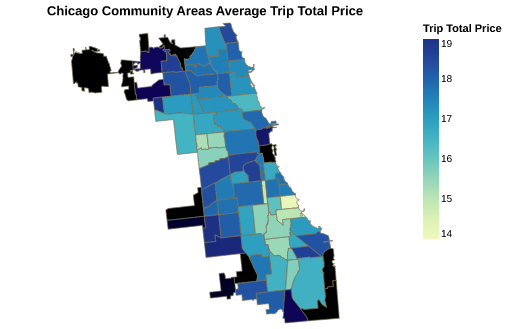

In [98]:
#capl= pick_up_stats['mean_total'].quantile(0.01)
capu= pick_up_statsTT['mean_total'].quantile(0.95)

alt.Chart(
    mergedTT,
    title="Chicago Community Areas Average Trip Total Price").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('mean_total:Q',scale=alt.Scale(domain=[14,19]),
              legend=alt.Legend(title='Trip Total Price')),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('mean_total:N', title='Price')
    ]
).properties(
    width=400
).project(
    type='albers'
)

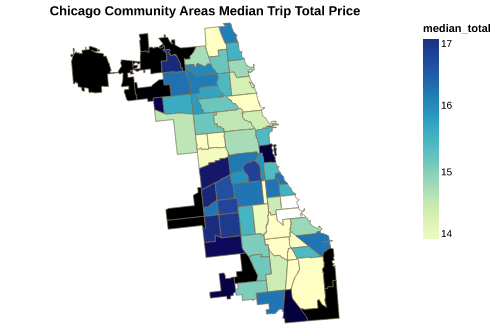

In [99]:
#capl= pick_up_stats['median_total'].quantile(0.2)
#capu= pick_up_stats['median_total'].quantile(0.8)

alt.Chart(
    mergedTT,
    title="Chicago Community Areas Median Trip Total Price").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('median_total:Q',scale=alt.Scale(domain=[14,17])),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('median_total:Q', title='Price')
    ]
).properties(
    width=400
).project(
    type='albers'
)

In [100]:
pick_up_statsTT.describe()

,community_area,mean_total,median_total,count
count,77.000000,77.000000,77.000000,77.000000
mean,39.000000,18.646893,16.469675,49049.467532
std,22.371857,4.652271,4.662123,118886.024106
min,1.000000,14.153605,9.730000,117.000000
25%,20.000000,16.903091,14.570000,3885.000000
50%,39.000000,17.765294,15.625000,9570.000000
75%,58.000000,18.658608,16.890000,32974.000000
max,77.000000,47.136045,45.100000,787204.000000


IT WOULD BE INTERESTING TO ALSO COUNT HOW MANY RIDES THERE ARE IN EACH NEIGHBORHOOD

<BarContainer object of 77 artists>

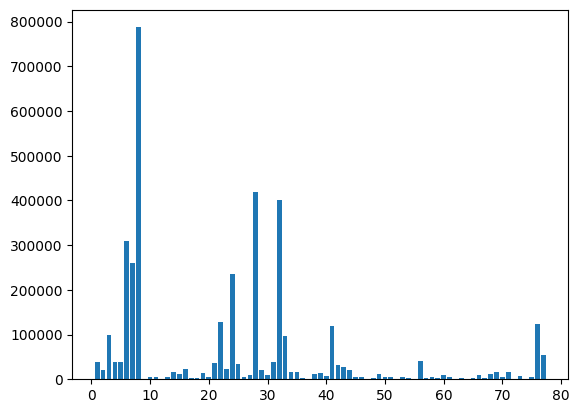

In [101]:
mergedTT
plt.bar(mergedTT['community_area'],mergedTT['count'])

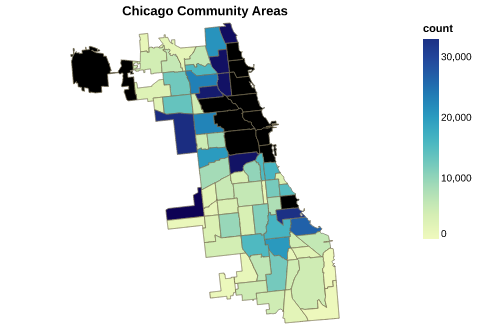

In [102]:
alt.Chart(
    mergedTT,
    title="Chicago Community Areas").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('count:Q',scale=alt.Scale(domain=[0,33000])),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('count:Q',title='Number of Rides')
    ]
).properties(
    width=400
).project(
    type='albers'
)

In [103]:
# could calculate rides per capita, or per total size of community area

### Fare Price Per Mile

In [104]:
pick_up_statsFpM=smalldf.groupby('Pickup Community Area')['Price Per Mile'].agg(mean_total='mean', median_total='median', count='count').reset_index().rename(columns={'Pickup Community Area': 'community_area'})
pick_up_statsFpM
#looked at median


,community_area,mean_total,median_total,count
0,1.0,3.600909,2.857143,38327
1,2.0,3.513689,3.030303,21103
2,3.0,3.965582,3.260870,99281
3,4.0,3.761323,3.294574,37886
4,5.0,4.197020,3.571429,37621
...,...,...,...,...
72,73.0,2.908940,2.272727,6391
73,74.0,3.490949,2.500000,499
74,75.0,2.946275,2.205882,4870
75,76.0,2.095117,1.943234,123282


In [105]:
mergedFpM=chicago_ca_df.merge(pick_up_statsFpM, on='community_area')

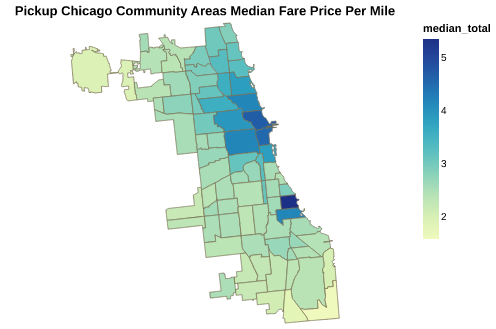

In [106]:
#capl= pick_up_stats['mean_total'].quantile(0.01)
capu= pick_up_statsTT['median_total'].quantile(0.95)

alt.Chart(
    mergedFpM,
    title="Pickup Chicago Community Areas Median Fare Price Per Mile ").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('median_total:Q'),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('median_total:Q', title='Price Per Mile')
    ]
).properties(
    width=400
).project(
    type='albers'
)


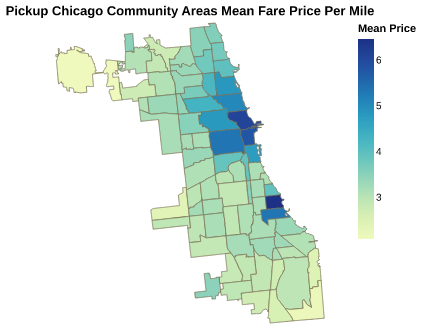

In [107]:
#capl= pick_up_stats['mean_total'].quantile(0.01)
capu= pick_up_statsTT['mean_total'].quantile(0.95)

pickupcaMeanFPM=alt.Chart(
    mergedFpM,
    title="Pickup Chicago Community Areas Mean Fare Price Per Mile ").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('mean_total:Q',
              legend=alt.Legend(title="Mean Price")),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('mean_total:Q', title='Price Per Mile')
    ]
).properties(
    width=300,
).project(
    type='albers'
)

pickupcaMeanFPM

### Total Trip Price Per Mile

In [108]:
pick_up_statsTTpM=smalldf.groupby('Pickup Community Area')['Trip Total Price Per Mile'].agg(mean_total='mean', median_total='median', count='count').reset_index().rename(columns={'Pickup Community Area': 'community_area'})
pick_up_statsTTpM

,community_area,mean_total,median_total,count
0,1.0,5.062095,3.800000,38327
1,2.0,4.825482,4.070000,21103
2,3.0,5.473490,4.402632,99281
3,4.0,5.249552,4.463636,37886
4,5.0,5.717780,4.880000,37621
...,...,...,...,...
72,73.0,4.023125,3.246000,6391
73,74.0,4.818528,3.364000,499
74,75.0,4.098334,3.152336,4870
75,76.0,2.982349,2.720238,123282


In [109]:
mergedTTpM=chicago_ca_df.merge(pick_up_statsTTpM, on='community_area')

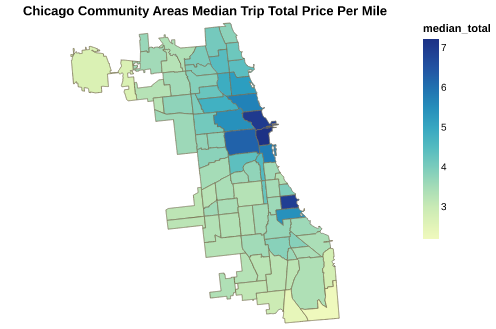

In [110]:
capu= pick_up_statsTT['median_total'].quantile(0.95)

alt.Chart(
    mergedTTpM,
    title="Chicago Community Areas Median Trip Total Price Per Mile ").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('median_total:Q'),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('median_total:Q', title='Price Per Mile')
    ]
).properties(
    width=400
).project(
    type='albers'
)


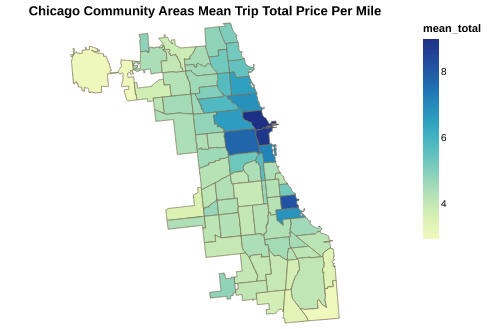

In [111]:
capu= pick_up_statsTT['median_total'].quantile(0.95)

alt.Chart(
    mergedTTpM,
    title="Chicago Community Areas Mean Trip Total Price Per Mile ").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('mean_total:Q'),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('mean_total:Q', title='Price Per Mile')
    ]
).properties(
    width=400
).project(
    type='albers'
)


### Seconds per Mile

In [112]:
pick_up_statsSpM=smalldf.groupby('Pickup Community Area')['Trip Seconds Per Mile'].agg(mean_total='mean', median_total='median', count='count').reset_index().rename(columns={'Pickup Community Area': 'community_area'})
pick_up_statsSpM

,community_area,mean_total,median_total,count
0,1.0,245.022669,233.720930,38327
1,2.0,253.567794,245.161290,21103
2,3.0,240.954785,234.000000,99281
3,4.0,259.242215,255.202740,37886
4,5.0,263.061395,259.655172,37621
...,...,...,...,...
72,73.0,201.337171,190.714286,6391
73,74.0,189.905064,184.800000,499
74,75.0,196.869484,184.978261,4870
75,76.0,116.466957,104.560440,123282


In [113]:
mergedSpM=chicago_ca_df.merge(pick_up_statsSpM, on='community_area')

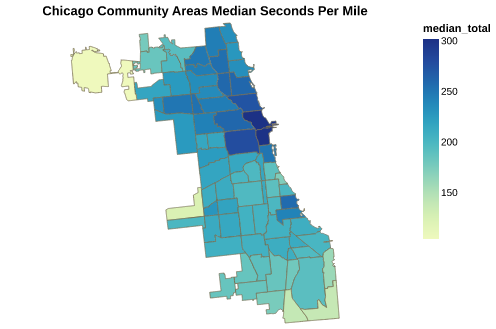

In [114]:
capu= pick_up_statsTT['median_total'].quantile(0.95)

alt.Chart(
    mergedSpM,
    title="Chicago Community Areas Median Seconds Per Mile ").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('median_total:Q'),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('median_total:Q', title='Price Per Mile')
    ]
).properties(
    width=400
).project(
    type='albers'
)

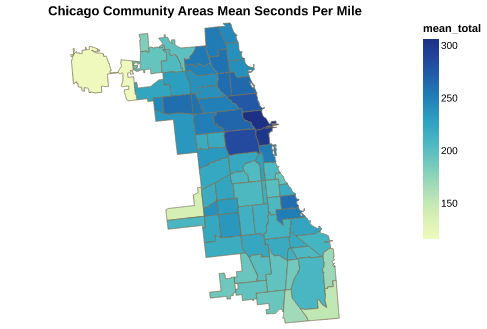

In [115]:
capu= pick_up_statsTT['mean_total'].quantile(0.95)

alt.Chart(
    mergedSpM,
    title="Chicago Community Areas Mean Seconds Per Mile ").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('mean_total:Q'),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('mean_total:Q', title='Price Per Mile')
    ]
).properties(
    width=400
).project(
    type='albers'
)

## Drop-off Stats

### Total Trips

In [116]:
drop_off_statsTT=smalldf.groupby('Dropoff Community Area')['Trip Total'].agg(mean_total='mean', median_total='median', count='count').reset_index().rename(columns={'Dropoff Community Area': 'community_area'})
mergedTTd=chicago_ca_df.merge(drop_off_statsTT, on='community_area')
drop_off_statsTT.describe()

,community_area,mean_total,median_total,count
count,77.000000,77.000000,77.000000,77.000000
mean,39.000000,18.851402,16.430065,49049.467532
std,22.371857,5.379402,5.185999,119598.152873
min,1.000000,14.432718,10.560000,91.000000
25%,20.000000,16.579009,14.230000,3479.000000
50%,39.000000,17.465773,15.570000,8379.000000
75%,58.000000,19.092332,16.485000,31114.000000
max,77.000000,51.419007,48.550000,770822.000000


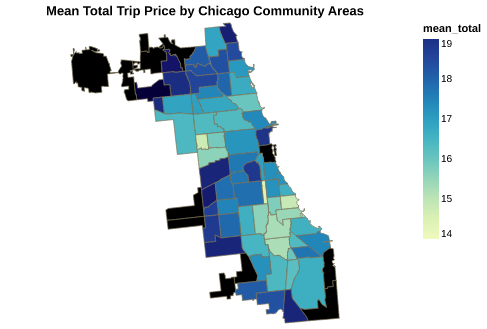

In [117]:
alt.Chart(
    mergedTTd,
    title="Mean Total Trip Price by Chicago Community Areas").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('mean_total:Q',scale=alt.Scale(domain=[14,19])),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('mean_total:Q', title='price')
    ]
).properties(
    width=400
).project(
    type='albers'
)

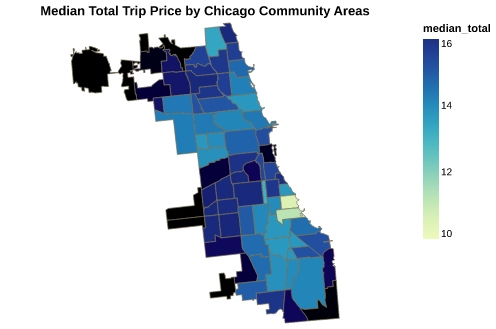

In [118]:
alt.Chart(
    mergedTTd,
    title="Median Total Trip Price by Chicago Community Areas").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('median_total:Q',scale=alt.Scale(domain=[10,16])),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('median_total', title='Median price')
    ]
).properties(
    width=400
).project(
    type='albers'
)

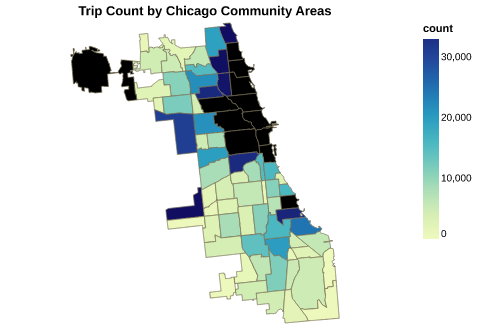

In [119]:
alt.Chart(
    mergedTTd,
    title="Trip Count by Chicago Community Areas").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('count:Q',scale=alt.Scale(domain=[0,33000])),
    tooltip=[
        alt.Tooltip('community_area:N', title='CA')
    ]
).properties(
    width=400
).project(
    type='albers'
)

### Fare Price Per Mile

In [120]:
drop_off_statsFpM=smalldf.groupby('Dropoff Community Area')['Price Per Mile'].agg(mean_total='mean', median_total='median', count='count').reset_index().rename(columns={'Dropoff Community Area': 'community_area'})
drop_off_statsFpM.head()

,community_area,mean_total,median_total,count
0,1.0,3.750630,3.000000,38313
1,2.0,3.805596,3.409091,19381
2,3.0,4.102459,3.409091,92000
3,4.0,4.060217,3.571429,38049
4,5.0,4.308412,3.676471,37172


In [121]:
mergedFpMd=chicago_ca_df.merge(drop_off_statsFpM, on='community_area')

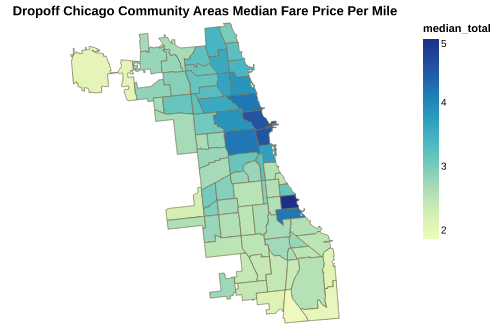

In [122]:

alt.Chart(
    mergedFpMd,
    title="Dropoff Chicago Community Areas Median Fare Price Per Mile ").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('median_total:Q'),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('median_total:Q', title='Price Per Mile')
    ]
).properties(
    width=400
).project(
    type='albers'
)


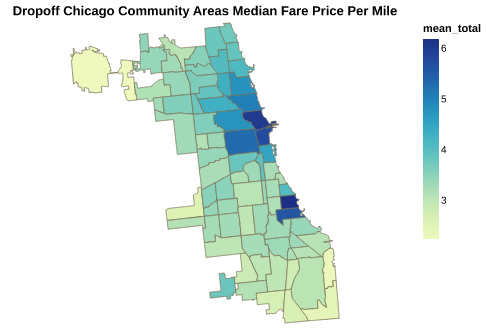

In [123]:
alt.Chart(
    mergedFpMd,
    title="Dropoff Chicago Community Areas Median Fare Price Per Mile ").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('mean_total:Q'),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('mean_total:Q', title='Price Per Mile')
    ]
).properties(
    width=400
).project(
    type='albers'
)


### Tota Price per Mile


In [124]:
drop_off_statsTTpMd=smalldf.groupby('Dropoff Community Area')['Trip Total Price Per Mile'].agg(mean_total='mean', median_total='median', count='count').reset_index().rename(columns={'Dropoff Community Area': 'community_area'})

In [125]:
mergedTTpMd=chicago_ca_df.merge(drop_off_statsTTpMd, on='community_area')

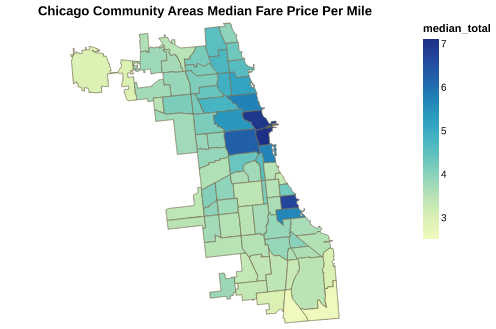

In [126]:

alt.Chart(
    mergedTTpMd,
    title="Chicago Community Areas Median Fare Price Per Mile ").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('median_total:Q'),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('median_total:Q', title='Price Per Mile')
    ]
).properties(
    width=400
).project(
    type='albers'
)


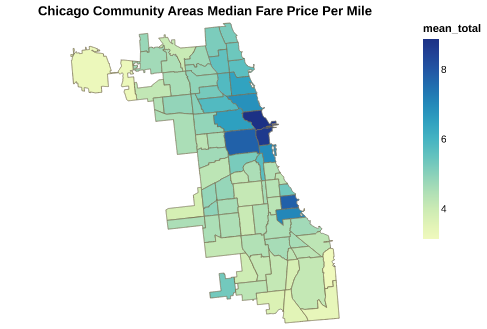

In [127]:
alt.Chart(
    mergedTTpMd,
    title="Chicago Community Areas Median Fare Price Per Mile ").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('mean_total:Q'),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('mean_total:Q', title='Price Per Mile')
    ]
).properties(
    width=400
).project(
    type='albers'
)


### Second per Mile

In [128]:
drop_off_statsSpM=smalldf.groupby('Dropoff Community Area')['Trip Seconds Per Mile'].agg(mean_total='mean', median_total='median', count='count').reset_index().rename(columns={'Dropoff Community Area': 'community_area'})

In [129]:
mergedSpMd=chicago_ca_df.merge(drop_off_statsSpM, on='community_area')

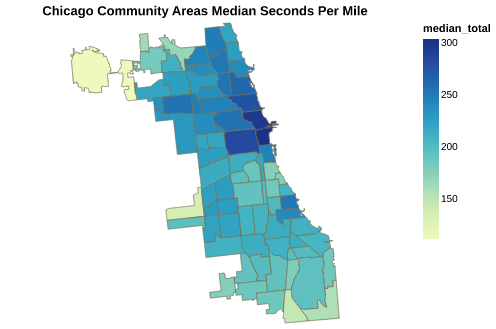

In [130]:
alt.Chart(
    mergedSpMd,
    title="Chicago Community Areas Median Seconds Per Mile ").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('median_total:Q'),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('median_total:Q', title='Price Per Mile')
    ]
).properties(
    width=400
).project(
    type='albers'
)


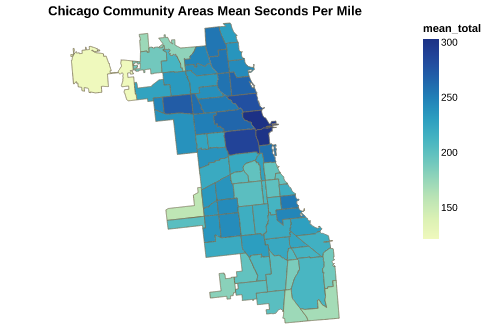

In [131]:
alt.Chart(
     mergedSpMd,
    title="Chicago Community Areas Mean Seconds Per Mile ").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('mean_total:Q'),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('mean_total:Q', title='Price Per Mile')
    ]
).properties(
    width=400
).project(
    type='albers'
)


## Differences

In [132]:
diff=pick_up_statsFpM.merge(drop_off_statsFpM, on='community_area', suffixes=('_pickup', '_dropoff'))
diff['mean_diff']=diff['mean_total_pickup']-diff['mean_total_dropoff']
diff['median_diff']=diff['median_total_pickup']-diff['median_total_dropoff']
diff['count_diff']=diff['count_pickup']-diff['count_dropoff']
diff.head()

,community_area,mean_total_pickup,median_total_pickup,count_pickup,mean_total_dropoff,median_total_dropoff,count_dropoff,mean_diff,median_diff,count_diff
0,1.0,3.600909,2.857143,38327,3.750630,3.000000,38313,-0.149721,-0.142857,14
1,2.0,3.513689,3.030303,21103,3.805596,3.409091,19381,-0.291907,-0.378788,1722
2,3.0,3.965582,3.260870,99281,4.102459,3.409091,92000,-0.136876,-0.148221,7281
3,4.0,3.761323,3.294574,37886,4.060217,3.571429,38049,-0.298894,-0.276855,-163
4,5.0,4.197020,3.571429,37621,4.308412,3.676471,37172,-0.111392,-0.105042,449


In [133]:
merged_diff=chicago_ca_df.merge(diff, on='community_area')
#merged_diff.head()

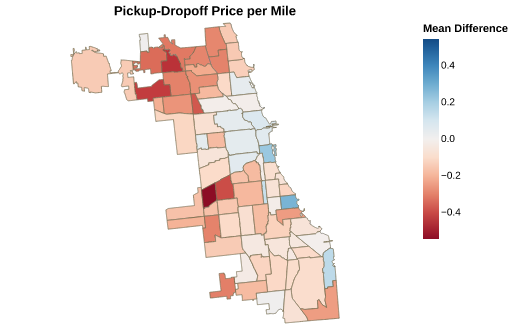

In [134]:
max_abs=np.nanmax(np.abs(merged_diff['mean_diff']))
max_abs

diff_pricepmile_chart= alt.Chart(
    merged_diff,
    title="Pickup-Dropoff Price per Mile").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('mean_diff:Q',scale=alt.Scale(scheme='redblue', domain=[-max_abs,max_abs]),
              legend=alt.Legend(title='Mean Difference')),
    tooltip=[
        alt.Tooltip('community_area:N', title='CA'),
        alt.Tooltip('mean_total_pickup:Q', title='Pickup'),
        alt.Tooltip('mean_total_dropoff:Q', title='Dropoff'),
        alt.Tooltip('mean_diff:Q', title='Difference')
    ]
).properties(
    width=400
).project(
    type='albers'
)

diff_pricepmile_chart

It can be observed that on the sorrounding areas, so those that are furtherst away fcrom downtwon have a higher price per mile.

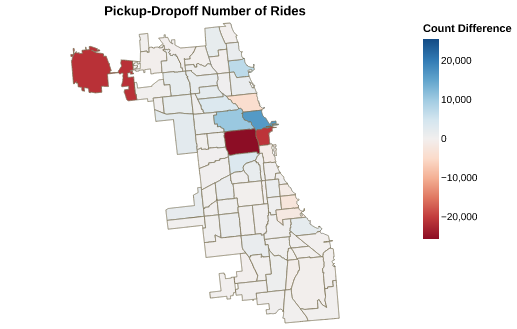

In [135]:
cap=np.nanpercentile(np.abs(merged_diff['count_diff']),95)

max_absC=np.nanmax(np.abs(merged_diff['count_diff']))
max_absC

diff_count_chart= alt.Chart(
    merged_diff,
    title="Pickup-Dropoff Number of Rides").mark_geoshape( # '#2a1d0c',
    stroke='#706545',
    strokeWidth=0.75
).encode(
    alt.Color('count_diff:Q',scale=alt.Scale(scheme='redblue', domain=[-max_absC,max_absC]),
    legend=alt.Legend(title='Count Difference')),
    tooltip=[
        alt.Tooltip('community_area_name:N', title='CA'),
        alt.Tooltip('count_pickup:Q', title='Pickup'),
        alt.Tooltip('count_dropoff:Q', title='Dropoff'),
        alt.Tooltip('count_diff:Q', title='Difference')
    ]
).properties(
    width=400
).project(
    type='albers'
)

diff_count_chart

#fix scale

# Regression

In [136]:
df2.head()

,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Census Tract,Dropoff Census Tract,Pickup Community Area,Dropoff Community Area,Fare,Tip,Additional Charges,Trip Total,Pickup Centroid Latitude,Pickup Centroid Longitude,Pickup Centroid Location,Dropoff Centroid Latitude,Dropoff Centroid Longitude,Dropoff Centroid Location
2,2024-01-31 23:45:00,2024-01-31 23:45:00,935.0,6.5,1.703105e+10,1.703108e+10,5.0,8.0,12.5,0.0,3.57,16.07,41.950546,-87.676182,POINT (-87.6761824959 41.9505456965),41.892073,-87.628874,POINT (-87.6288741572 41.8920726347)
3,2024-01-31 23:45:00,2024-01-31 23:45:00,596.0,2.4,1.703107e+10,1.703106e+10,7.0,6.0,10.0,2.0,1.23,13.23,41.914616,-87.631717,POINT (-87.6317173661 41.9146162864),41.942577,-87.647079,POINT (-87.6470785093 41.942577185)
6,2024-01-31 23:45:00,2024-01-31 23:45:00,1315.0,8.7,1.703108e+10,1.703183e+10,8.0,28.0,15.0,0.0,3.47,18.47,41.892042,-87.631864,POINT (-87.6318639497 41.8920421365),41.879067,-87.657005,POINT (-87.657005027 41.8790669938)
8,2024-01-31 23:45:00,2024-01-31 23:45:00,341.0,1.0,1.703108e+10,1.703108e+10,8.0,8.0,5.0,0.0,2.32,7.32,41.892508,-87.626215,POINT (-87.6262149064 41.8925077809),41.902788,-87.626146,POINT (-87.6261455896 41.9027880476)
14,2024-01-31 23:45:00,2024-01-31 23:45:00,949.0,3.6,1.703184e+10,1.703144e+10,41.0,44.0,10.0,0.0,4.05,14.05,41.790469,-87.601285,POINT (-87.6012851221 41.7904693995),41.748211,-87.610075,POINT (-87.6100749663 41.7482105124)


In [137]:
airport_tracts = [
    17031980000, #midway,
    17031980000 #ohare,
    # add any other significant O'Hare tracts if there are multiple
]

df2['airport_pick'] = df2['Pickup Census Tract'].isin(airport_tracts)
df2['airport_drop'] = df2['Dropoff Census Tract'].isin(airport_tracts)

/tmp/ipykernel_36723/1634714533.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['airport_pick'] = df2['Pickup Census Tract'].isin(airport_tracts)
/tmp/ipykernel_36723/1634714533.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['airport_drop'] = df2['Dropoff Census Tract'].isin(airport_tracts)


We are going to do a linear regression
- use hours of day
- use days of week
- account for MLK holiday as special January 15 (different behavior for monday)

In [138]:
df3=df2[['Trip Start Timestamp','Trip End Timestamp','Trip Seconds',
       'Trip Miles',
       'Pickup Community Area',
       'Dropoff Community Area', 'Fare', 'Tip', 'Additional Charges',
       'Trip Total','Pickup Census Tract','Dropoff Census Tract']].copy()
df3.head()

,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Community Area,Dropoff Community Area,Fare,Tip,Additional Charges,Trip Total,Pickup Census Tract,Dropoff Census Tract
2,2024-01-31 23:45:00,2024-01-31 23:45:00,935.0,6.5,5.0,8.0,12.5,0.0,3.57,16.07,1.703105e+10,1.703108e+10
3,2024-01-31 23:45:00,2024-01-31 23:45:00,596.0,2.4,7.0,6.0,10.0,2.0,1.23,13.23,1.703107e+10,1.703106e+10
6,2024-01-31 23:45:00,2024-01-31 23:45:00,1315.0,8.7,8.0,28.0,15.0,0.0,3.47,18.47,1.703108e+10,1.703183e+10
8,2024-01-31 23:45:00,2024-01-31 23:45:00,341.0,1.0,8.0,8.0,5.0,0.0,2.32,7.32,1.703108e+10,1.703108e+10
14,2024-01-31 23:45:00,2024-01-31 23:45:00,949.0,3.6,41.0,44.0,10.0,0.0,4.05,14.05,1.703184e+10,1.703144e+10


In [139]:
df3['Trip Minutes']=df3['Trip Seconds']/60
df3=df3[(df3['Trip Miles']>0.2)& (df3['Trip Minutes']>2)&(df3['Fare']>0)]
#making sure we get valid answers
df3=df3[df3['Fare']<df3['Fare'].quantile(0.999)]
#getting rid of extremes from the top
df3['hour']=df3['Trip Start Timestamp'].dt.hour
df3['day']=df3['Trip Start Timestamp'].dt.dayofweek #0=Monday 6=Sunday
df3['is_holiday']=df3['Trip Start Timestamp'].dt.date==pd.Timestamp('2024-01-15').date()
df3.head()


,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Community Area,Dropoff Community Area,Fare,Tip,Additional Charges,Trip Total,Pickup Census Tract,Dropoff Census Tract,Trip Minutes,hour,day,is_holiday
2,2024-01-31 23:45:00,2024-01-31 23:45:00,935.0,6.5,5.0,8.0,12.5,0.0,3.57,16.07,1.703105e+10,1.703108e+10,15.583333,23,2,False
3,2024-01-31 23:45:00,2024-01-31 23:45:00,596.0,2.4,7.0,6.0,10.0,2.0,1.23,13.23,1.703107e+10,1.703106e+10,9.933333,23,2,False
6,2024-01-31 23:45:00,2024-01-31 23:45:00,1315.0,8.7,8.0,28.0,15.0,0.0,3.47,18.47,1.703108e+10,1.703183e+10,21.916667,23,2,False
8,2024-01-31 23:45:00,2024-01-31 23:45:00,341.0,1.0,8.0,8.0,5.0,0.0,2.32,7.32,1.703108e+10,1.703108e+10,5.683333,23,2,False
14,2024-01-31 23:45:00,2024-01-31 23:45:00,949.0,3.6,41.0,44.0,10.0,0.0,4.05,14.05,1.703184e+10,1.703144e+10,15.816667,23,2,False


Need to think about airport effect. So going to add O'Hare and Midway into the regression as indicator variables.


In [140]:
#Ohare 76
#Gardfield Ridge and Clearing for Midway 64,56
#df3['airport_pick']=df3['Pickup Community Area'].isin([76])
#df3['airport_drop']=df3['Dropoff Community Area'].isin([76])
#df3.head()
# Find the candidate airport tracts inside CA 56 and 64
midway_candidates = df3[df3['Pickup Community Area'].isin([56, 64])]
tract_stats = (midway_candidates.groupby('Pickup Census Tract')
                                 .agg(mean_fare=('Fare', 'mean'),
                                      mean_miles=('Trip Miles', 'mean'),
                                      n=('Fare', 'size'))
                                 .sort_values('mean_fare', ascending=False))
print(tract_stats.head(10))

                     mean_fare  mean_miles      n
Pickup Census Tract                              
1.703198e+10         28.469538   12.594007  38343
1.703164e+10         20.277778   10.658730     63
1.703156e+10         19.350649   10.909091     77
1.703156e+10         19.186047    9.448837     86
1.703184e+10         18.890504    9.438372    516
1.703164e+10         18.000000    9.391111     45
1.703156e+10         17.500000    6.863934     61
1.703156e+10         16.669381    8.901629    307
1.703164e+10         15.810185    7.762037    108
1.703164e+10         15.658284    8.128698    338


In [141]:
midway_tract = int(tract_stats.index[0])
print(f"Midway tract: {midway_tract}")

Midway tract: 17031980100


In [142]:
ohare_candidates = df3[df3['Pickup Community Area'] == 76]
ohare_tracts = (ohare_candidates.groupby('Pickup Census Tract')
                                 .agg(mean_fare=('Fare', 'mean'),
                                      mean_miles=('Trip Miles', 'mean'),
                                      n=('Fare', 'size'))
                                 .sort_values('mean_fare', ascending=False))
print(ohare_tracts.head(5))

                     mean_fare  mean_miles       n
Pickup Census Tract                               
1.703198e+10         33.972355   17.001399  117852
1.703177e+10         17.719780    8.980128    1092
1.703176e+10         15.618821    7.237833    2630
1.703177e+10         15.543478    8.252174      46
1.703176e+10         14.278846    6.325000      52


In [143]:
ohare_tract = int(ohare_tracts.index[0])
print(f"Ohare_tract: {ohare_tract}")

Ohare_tract: 17031980000


In [144]:
df3['midway_pick'] = df3['Pickup Census Tract'].isin([17031980100])
df3['midway_drop'] = df3['Dropoff Census Tract'].isin([17031980100])
df3['ohare_pick'] = df3['Pickup Census Tract'].isin([17031980000])
df3['ohare_drop'] = df3['Dropoff Census Tract'].isin([17031980000])

In [145]:
df3.head()

,Trip Start Timestamp,Trip End Timestamp,Trip Seconds,Trip Miles,Pickup Community Area,Dropoff Community Area,Fare,Tip,Additional Charges,Trip Total,Pickup Census Tract,Dropoff Census Tract,Trip Minutes,hour,day,is_holiday,midway_pick,midway_drop,ohare_pick,ohare_drop
2,2024-01-31 23:45:00,2024-01-31 23:45:00,935.0,6.5,5.0,8.0,12.5,0.0,3.57,16.07,1.703105e+10,1.703108e+10,15.583333,23,2,False,False,False,False,False
3,2024-01-31 23:45:00,2024-01-31 23:45:00,596.0,2.4,7.0,6.0,10.0,2.0,1.23,13.23,1.703107e+10,1.703106e+10,9.933333,23,2,False,False,False,False,False
6,2024-01-31 23:45:00,2024-01-31 23:45:00,1315.0,8.7,8.0,28.0,15.0,0.0,3.47,18.47,1.703108e+10,1.703183e+10,21.916667,23,2,False,False,False,False,False
8,2024-01-31 23:45:00,2024-01-31 23:45:00,341.0,1.0,8.0,8.0,5.0,0.0,2.32,7.32,1.703108e+10,1.703108e+10,5.683333,23,2,False,False,False,False,False
14,2024-01-31 23:45:00,2024-01-31 23:45:00,949.0,3.6,41.0,44.0,10.0,0.0,4.05,14.05,1.703184e+10,1.703144e+10,15.816667,23,2,False,False,False,False,False


In [146]:
from google.colab import files
df3.to_csv('df3c.csv', index=False)
files.download('df3c.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>